# 04 — Datenbereinigung (Multiple Imputation)

Dieses Notebook bereinigt die in **Notebook 03** erstellte Roh-Panel-Datenbank
`Created DBs/final_database_raw.csv` (**1904** Zeilen = 119 Länder × 16 Jahre 2007–2022;
2 Zielvariablen + 35 Features).

**Methodischer Rahmen**
- Geplant ist eine **Multiple Imputation** (Amelia bzw. `mice`) der **Features**.
  Die **Zielvariablen (HDI, Happiness_Score) werden NICHT imputiert.**
- **Dieser erste Schritt** legt die Diagnose-Grundlage: eine **Land × Variable-Missingness-Map**
  (`Amelia::missmap` / `naniar::vis_miss` + aggregierte Heatmap) und die **exakte Zählung**,
  bei wie vielen Ländern eine Variable *komplett* (alle 16 Jahre) fehlt.
- **Strukturelle Lücken** (Land ganz ohne Variable) sind durch zeitliche Verfahren **nicht**
  schließbar und müssen in der Imputationsstrategie gesondert behandelt werden.

> Umgebung: **R** (Kernel `ir`). Eingelesen wird die CSV aus NB 03; fehlende Werte sind dort
> als `n/a` kodiert.

## 0 — Setup

In [1]:
# ── Bibliotheken ───────────────────────────────────────────────────────
suppressPackageStartupMessages({
  library(readr)    # CSV-Einlesen
  library(dplyr)    # Datenmanipulation
  library(tidyr)    # pivot_longer
  library(ggplot2)  # Heatmap
  library(naniar)   # vis_miss / Missingness-Diagnostik
  library(Amelia)   # missmap + (spätere) Multiple Imputation
  library(writexl)  # Excel-Export der Übersichten
})

set.seed(42)  # Reproduzierbarkeit
options(repr.plot.width = 11, repr.plot.height = 7)  # Plotgröße im Notebook

# ── Pfade (Arbeitsverzeichnis = code/, analog zu NB 03) ────────────────
RAW_DB     <- file.path("..", "Created DBs", "Raw DBs")      # Eingang (unbereinigt, aus NB 03)
CLEANED_DB <- file.path("..", "Created DBs", "Cleaned DBs")  # Ausgang (bereinigt)
dir.create(CLEANED_DB, recursive = TRUE, showWarnings = FALSE)
RAW_PATH   <- file.path(RAW_DB, "final_database_raw.csv")

# ── Roh-DB einlesen (fehlende Werte sind als 'n/a' kodiert) ────────────
df <- readr::read_csv(
  RAW_PATH,
  na = c("", "NA", "n/a", "N/A"),
  show_col_types = FALSE
)

cat(sprintf("Eingelesen: %d Zeilen x %d Spalten\n", nrow(df), ncol(df)))
cat(sprintf("Zeitraum: %d-%d | Laender: %d\n",
            min(df$Year), max(df$Year), dplyr::n_distinct(df$ISO3)))

Eingelesen: 1904 Zeilen x 42 Spalten


Zeitraum: 2007-2022 | Laender: 119


## 1 — Datenstruktur & Spaltenrollen

In [2]:
# ── Spaltenrollen festlegen ────────────────────────────────────────────
id_cols      <- c("ISO3", "Country_Name", "Year")
target_cols  <- c("HDI", "Happiness_Score")
feature_cols <- setdiff(names(df), c(id_cols, target_cols))
value_cols   <- c(target_cols, feature_cols)

N_COUNTRIES <- dplyr::n_distinct(df$ISO3)
N_YEARS     <- dplyr::n_distinct(df$Year)

cat(sprintf("ID-Spalten    : %d  (%s)\n", length(id_cols), paste(id_cols, collapse = ", ")))
cat(sprintf("Zielvariablen : %d  (%s) -- werden NICHT imputiert\n",
            length(target_cols), paste(target_cols, collapse = ", ")))
cat(sprintf("Features      : %d\n", length(feature_cols)))

# ── Gesamt-Fehlanteil ──────────────────────────────────────────────────
n_miss_feat  <- sum(is.na(df[feature_cols]))
n_cells_feat <- nrow(df) * length(feature_cols)
cat(sprintf("\nFehlende Feature-Zellen: %d von %d (%.1f%%)\n",
            n_miss_feat, n_cells_feat, 100 * n_miss_feat / n_cells_feat))
cat(sprintf("Fehlende Zielwerte -> HDI: %d | Happiness_Score: %d\n",
            sum(is.na(df$HDI)), sum(is.na(df$Happiness_Score))))

ID-Spalten    : 3  (ISO3, Country_Name, Year)


Zielvariablen : 2  (HDI, Happiness_Score) -- werden NICHT imputiert


Features      : 37



Fehlende Feature-Zellen: 6889 von 70448 (9.8%)


Fehlende Zielwerte -> HDI: 0 | Happiness_Score: 123


## 2 — Land × Variable: Missingness-Map

Drei Sichten auf dieselbe Lücken-Struktur:
- **2a** `Amelia::missmap` — alle Land-Jahr-Beobachtungen × Variablen
- **2b** `naniar::vis_miss` — Fehlanteil je Variable über alle Beobachtungen
- **2c** aggregierte **Land × Variable**-Heatmap (Anteil fehlender Jahre je Land/Feature) —
  macht **strukturelle Lücken** (ganzes Land ohne Variable) unmittelbar sichtbar.

### 2a — `Amelia::missmap`

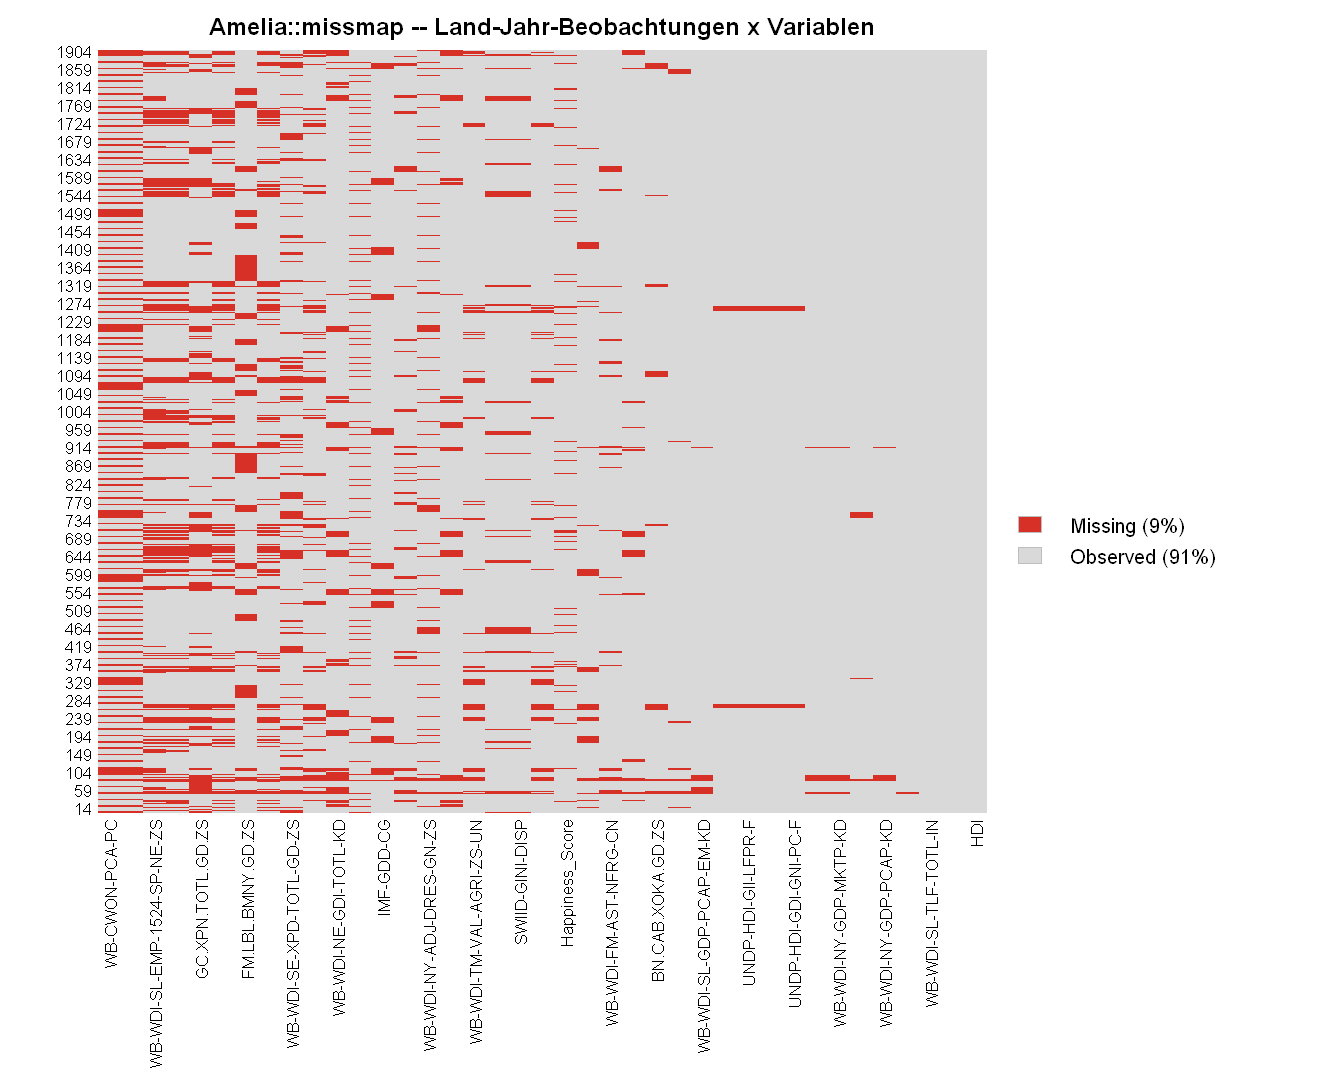

In [3]:
options(repr.plot.width = 11, repr.plot.height = 9)
Amelia::missmap(
  as.data.frame(df[value_cols]),
  main       = "Amelia::missmap -- Land-Jahr-Beobachtungen x Variablen",
  col        = c("#d73027", "grey85"),   # fehlend / beobachtet
  rank.order = TRUE,
  margins    = c(11, 4)
)

### 2b — `naniar::vis_miss`

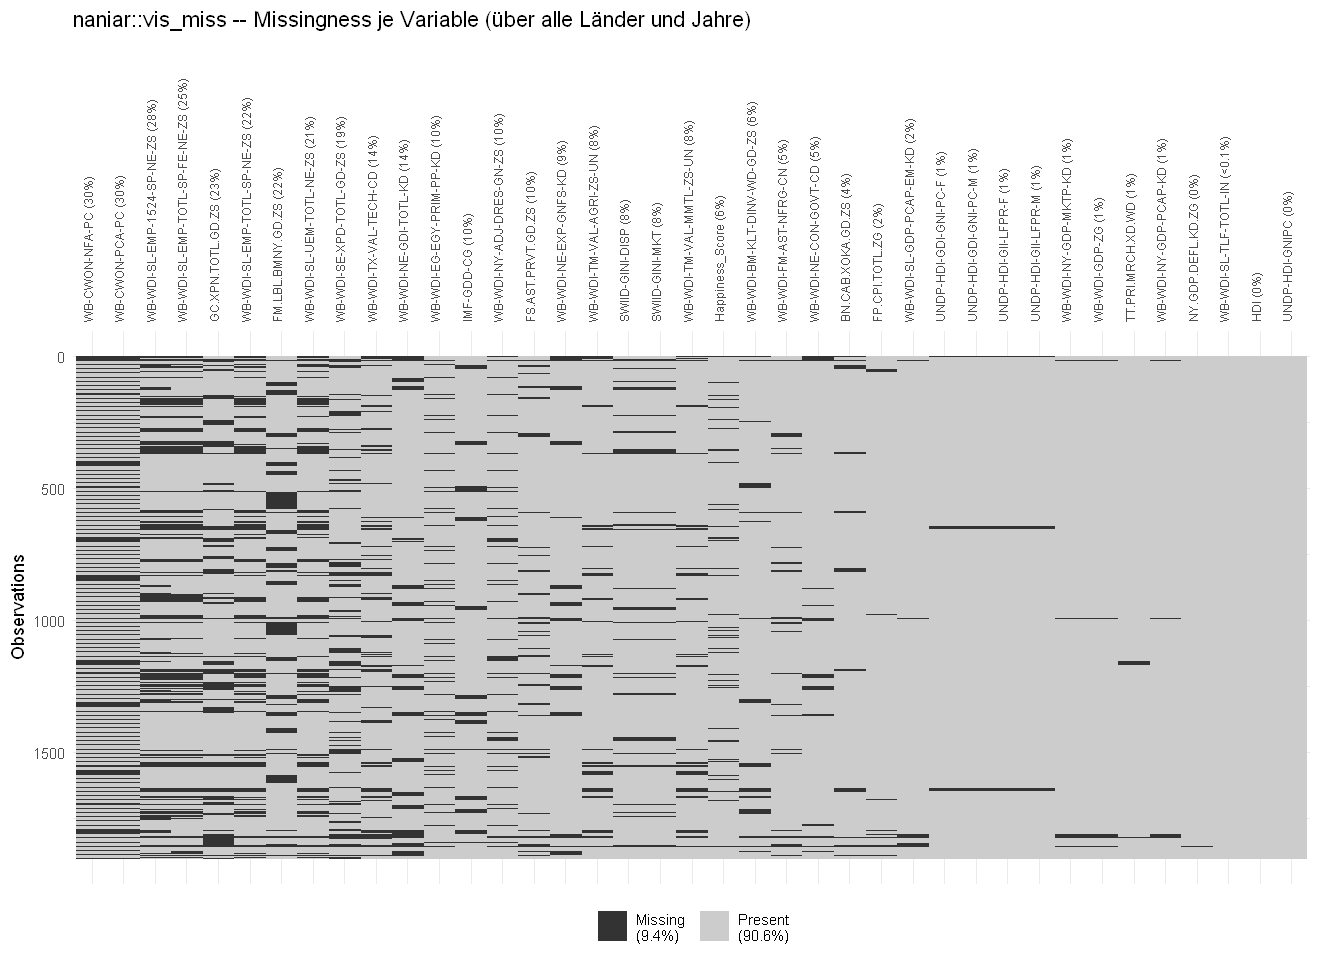

In [4]:
options(repr.plot.width = 11, repr.plot.height = 8)
naniar::vis_miss(df[value_cols], sort_miss = TRUE, warn_large_data = FALSE) +
  ggplot2::theme(axis.text.x = ggplot2::element_text(angle = 90, hjust = 0, size = 7)) +
  ggplot2::labs(title = "naniar::vis_miss -- Missingness je Variable (über alle Länder und Jahre)")

## 3 — Exakte Zählung: komplett fehlende Länder je Variable

Eine Variable gilt für ein Land als **komplett fehlend**, wenn in **allen 16 Jahren** kein Wert
vorliegt. Dies ist die Grundlage für die Behandlung **struktureller Lücken** in der Imputation.

In [5]:
# Logische Matrix Land x Feature: TRUE = Land hat fuer Feature keinen einzigen Wert
iso <- sort(unique(df$ISO3))
allna_mat <- sapply(feature_cols, function(v)
  tapply(df[[v]], df$ISO3, function(x) all(is.na(x)))[iso])
rownames(allna_mat) <- iso

# Tabelle je Variable
cm_var <- data.frame(
  Variable           = feature_cols,
  n_Länder_komplett_fehlend = as.integer(colSums(allna_mat)),
  Anteil_Länder_pct = round(100 * colSums(allna_mat) / length(iso), 1),
  Länder            = vapply(feature_cols,
                              function(v) paste(iso[allna_mat[, v]], collapse = ", "),
                              character(1)),
  row.names = NULL, stringsAsFactors = FALSE
)
cm_var <- cm_var[order(-cm_var$n_Länder_komplett_fehlend), ]

# Kennzahlen
n_pairs      <- sum(allna_mat)          # (Land,Variable)-Paare komplett fehlend
struct_cells <- n_pairs * N_YEARS       # entsprechende Zellen
cat(sprintf("Variablen mit >=1 komplett fehlendem Land: %d von %d\n",
            sum(cm_var$n_Länder_komplett_fehlend > 0), length(feature_cols)))
cat(sprintf("(Land,Variable)-Paare komplett fehlend: %d  ->  %d strukturelle Zellen (%.0f%% aller fehlenden Feature-Zellen)\n",
            n_pairs, struct_cells, 100 * struct_cells / n_miss_feat))

cm_var

Variablen mit >=1 komplett fehlendem Land: 24 von 37


(Land,Variable)-Paare komplett fehlend: 105  ->  1680 strukturelle Zellen (24% aller fehlenden Feature-Zellen)


,Variable,n_Länder_komplett_fehlend,Anteil_Länder_pct,Länder
,<chr>,<int>,<dbl>,<chr>
33,FM.LBL.BMNY.GD.ZS,20,16.8,"AUT, BEL, CYP, DEU, ESP, EST, FIN, FRA, GRC, HRV, IRL, ITA, LTU, LUX, LVA, MLT, NLD, PRT, SVK, SVN"
32,GC.XPN.TOTL.GD.ZS,14,11.8,"BEN, CHN, GIN, HKG, MNE, MRT, NER, NGA, PAK, SLE, TCD, VEN, VNM, YEM"
34,IMF-GDD-CG,11,9.2,"ARE, CHN, EGY, GEO, KHM, NLD, PAN, PHL, TJK, TZA, UZB"
25,WB-CWON-NFA-PC,8,6.7,"AFG, CYP, HKG, ISR, MNE, NZL, SRB, UZB"
26,WB-CWON-PCA-PC,8,6.7,"AFG, CYP, HKG, ISR, MNE, NZL, SRB, UZB"
23,WB-WDI-NE-GDI-TOTL-KD,5,4.2,"AFG, MWI, NGA, VEN, YEM"
24,WB-WDI-SE-XPD-TOTL-GD-ZS,5,4.2,"BIH, IRQ, MKD, MNE, NGA"
21,WB-WDI-BM-KLT-DINV-WD-GD-ZS,4,3.4,"ECU, NPL, TCD, TZA"
22,WB-WDI-NE-EXP-GNFS-KD,4,3.4,"AFG, MWI, NGA, VEN"


In [6]:
# Gegenstück: wie viele Variablen fehlen je Land komplett?
cm_country <- data.frame(
  ISO3                 = iso,
  n_Variablen_komplett_fehlend = as.integer(rowSums(allna_mat)),
  row.names = NULL, stringsAsFactors = FALSE
)
cm_country$Country_Name <- df$Country_Name[match(cm_country$ISO3, df$ISO3)]
cm_country <- cm_country[order(-cm_country$n_Variablen_komplett_fehlend),
                         c("ISO3", "Country_Name", "n_Variablen_komplett_fehlend")]

cat(sprintf("Laender mit >=1 komplett fehlender Variable: %d von %d\n",
            sum(cm_country$n_Variablen_komplett_fehlend > 0), length(iso)))
head(cm_country, 25)

Laender mit >=1 komplett fehlender Variable: 57 von 119


,ISO3,Country_Name,n_Variablen_komplett_fehlend
,<chr>,<chr>,<int>
114,VEN,"Venezuela, RB",8
103,TCD,Chad,6
73,MNE,Montenegro,5
79,NGA,Nigeria,5
1,AFG,Afghanistan,4
21,CHN,China,4
44,HKG,"Hong Kong SAR, China",4
26,CYP,Cyprus,3
76,MWI,Malawi,3


### Export der Übersichten

Beide Tabellen (`cm_var`, `cm_country`) werden in **eine** Excel-Datei mit zwei Tabellenblättern
geschrieben — Ablage in `Created Files for Analysis/missingness_uebersicht.xlsx`.

In [7]:
# ── Export: beide Übersichten in EINE Excel-Datei (zwei Tabellenblätter) ──
ANALYSIS_DIR <- file.path("Created Files for Analysis")
xlsx_path    <- file.path(ANALYSIS_DIR, "missingness_uebersicht.xlsx")

writexl::write_xlsx(
  list(
    "Komplett_fehlend_je_Variable" = cm_var,      # je Feature (35 Zeilen)
    "Komplett_fehlend_je_Land"     = cm_country   # je Land   (119 Zeilen)
  ),
  path = xlsx_path
)

cat("Gespeichert:", normalizePath(xlsx_path), "\n")
cat(sprintf("  Blatt 1 'Komplett_fehlend_je_Variable': %d Zeilen x %d Spalten\n",
            nrow(cm_var), ncol(cm_var)))
cat(sprintf("  Blatt 2 'Komplett_fehlend_je_Land'    : %d Zeilen x %d Spalten\n",
            nrow(cm_country), ncol(cm_country)))

Gespeichert: C:\Users\maier\OneDrive\Dokumente\_Studium\Bachelorarbeit\Practical Analysis\Explaining-Well-Being\code\Created Files for Analysis\missingness_uebersicht.xlsx 


  Blatt 1 'Komplett_fehlend_je_Variable': 37 Zeilen x 4 Spalten


  Blatt 2 'Komplett_fehlend_je_Land'    : 119 Zeilen x 3 Spalten


## 4 — Bereinigung Schritt 1: Life Satisfaction via Predictive Mean Matching (PMM)

**Ziel:** die **123 Lücken** der subjektiven Zielvariable *Life Satisfaction*
(`Happiness_Score`, WHR-LS) füllen. Methodik nach van Buuren, *Flexible Imputation of Missing
Data*, [§3.4 Predictive Mean Matching](https://stefvanbuuren.name/fimd/sec-pmm.html).

**Warum PMM?** Für jeden fehlenden Wert werden *d* Spender-Beobachtungen mit dem ähnlichsten
linearen Vorhersagewert gesucht und einer davon zufällig gezogen (Algorithmus 3.3,
Type-1-Matching). Die Imputationen sind dadurch **tatsächlich beobachtete LS-Werte** → automatisch
im gültigen Bereich der Cantril-Leiter (0–10), realistisch und robust gegenüber Nicht-Normalität.
Default **d = 5 Spender** (van Buurens Kompromiss zwischen Verzerrung und Duplikation); PMM ist hier
geeignet, da deutlich < 50 % der LS-Werte fehlen.

**Imputationsmodell** — bewusst nur **vollständige** Prädiktoren, damit Schritt 1 unabhängig von
Schritt 2 ist:

$$\text{Happiness\_Score} \sim \text{HDI} + \log(\text{GNI p.c.}) + \text{Land-FE (ISO3)} + \text{Year}$$

- **Land-Fixeffekte** sind hier besonders belastbar: jedes Land hat per Stichprobenkriterium
  **≥ 12 beobachtete LS-Werte** (max. 4 Lücken/Land) — die Spender stammen faktisch aus dem eigenen
  Länderniveau.
- **HDI** (0 % fehlend) ist der stärkste Hilfsprädiktor; **log(GNI p.c.)** ergänzt das
  Einkommenssignal; **Year** fängt den globalen Zeittrend.
- **HDI ist hier zulässig:** Der Ausschluss der Zielvariablen in §5.5 gilt für die
  **Indikator-Imputation (Schritt 2)** — dort dürfen HDI/LS nicht als Prädiktoren
  auftauchen (keine Zirkularität zwischen Imputation und Analyse). Innerhalb der
  Zielvariablen-Bereinigung ist HDI als vollständige zweite Zielvariable der beste
  verfügbare Hilfsprädiktor.

**m = 20** Imputationen (geringer Monte-Carlo-Fehler; dasselbe *m* ist für Schritt 2/Amelia
vorgesehen, damit die *m* vervollständigten Datensätze 1:1 zusammenpassen), Seed = 42.

In [8]:
# ── mice-Input: LS + ausschließlich VOLLSTÄNDIGE Prädiktoren ───────────
pmm_dat <- df %>%
  dplyr::transmute(
    Happiness_Score = Happiness_Score,
    HDI             = HDI,                      # 0 % fehlend, stärkster Hilfsprädiktor (Zielvariable; §5.5-Ausschluss gilt nur für Schritt 2)
    logGNI          = log(`UNDP-HDI-GNIPC`),    # GNI p.c. (0 % fehlend), log für Linearität
    ISO3            = factor(ISO3),             # Land-Fixeffekte (>= 12 LS-Werte je Land)
    Year            = Year                      # globaler Zeittrend
  )
stopifnot(sum(is.na(pmm_dat[, -1])) == 0)        # Prädiktoren wirklich vollständig

meth <- mice::make.method(pmm_dat)               # -> nur Happiness_Score = "pmm"
pred <- mice::make.predictorMatrix(pmm_dat)
print(meth)

# Multiple Imputation via PMM (Algorithmus 3.3, Type-1-Matching, d = 5 Spender)
imp_ls <- mice::mice(pmm_dat, m = 20, method = meth, predictorMatrix = pred,
                     donors = 5L, maxit = 5, seed = 42, printFlag = FALSE)
cat(sprintf("\nmice fertig: %d fehlende LS-Werte  x  m = %d  imputiert\n",
            nrow(imp_ls$imp$Happiness_Score), imp_ls$m))

Happiness_Score             HDI          logGNI            ISO3            Year 
          "pmm"              ""              ""              ""              "" 



mice fertig: 123 fehlende LS-Werte  x  m = 20  imputiert


Beobachtet  min/Mittel/max: 1.28 / 5.54 / 7.97


Imputiert   min/Mittel/max: 2.18 / 5.34 / 7.97


Alle Imputationen im beobachteten Bereich [1.28, 7.97]: TRUE  (PMM extrapoliert nicht)


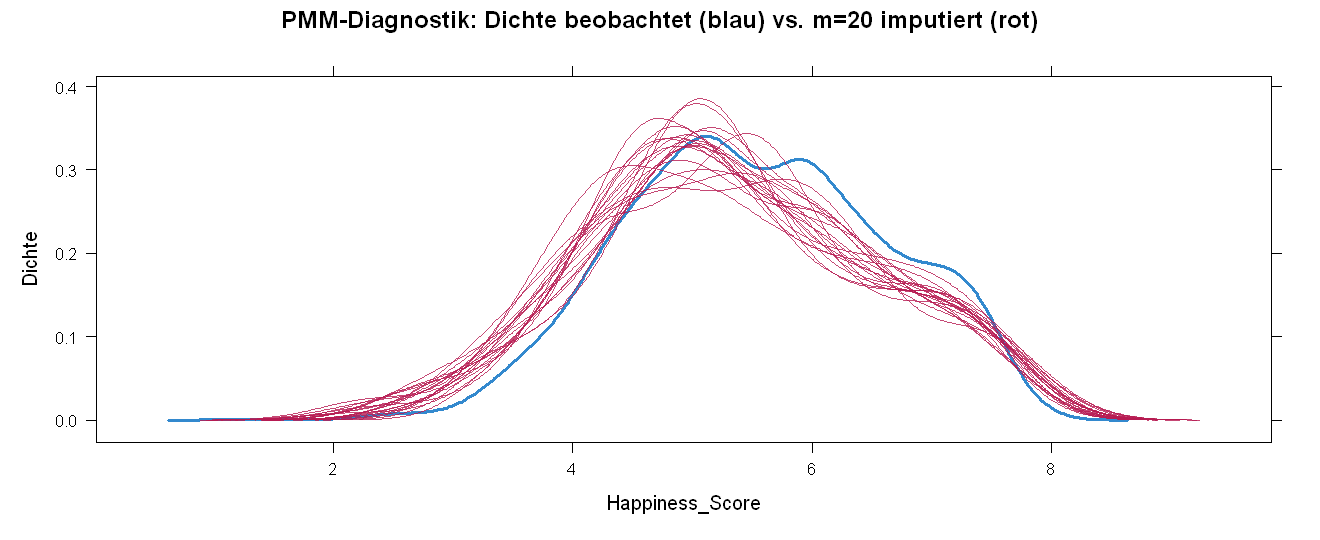

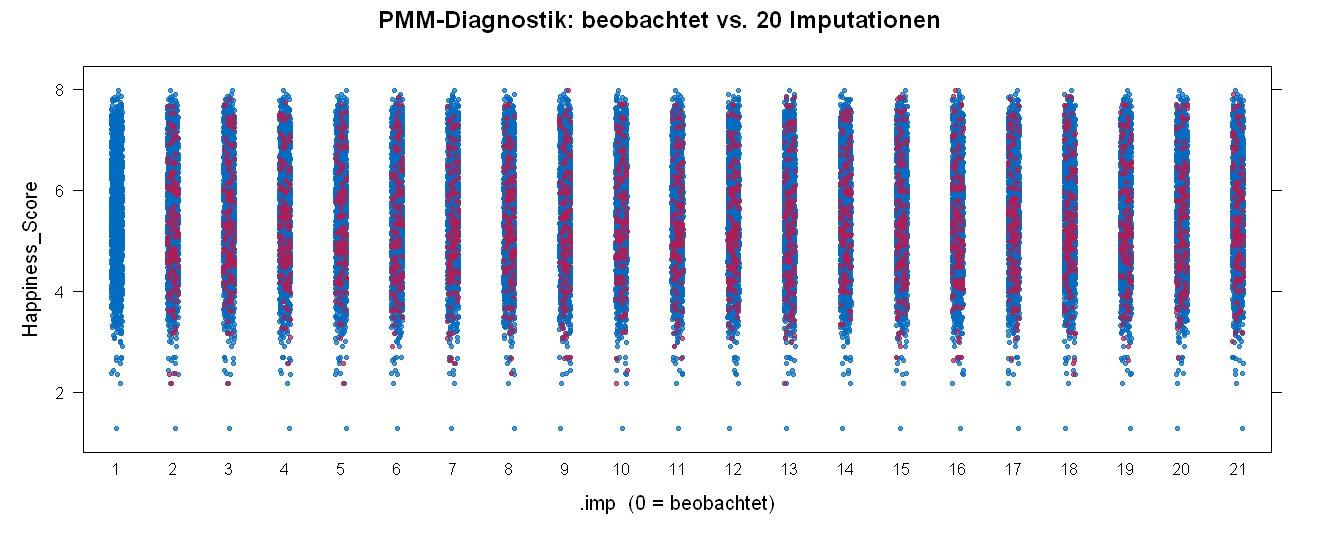

In [9]:
# ── Diagnostik (FIMD §3.4): imputiert vs. beobachtet ───────────────────
obs  <- df$Happiness_Score[!is.na(df$Happiness_Score)]
impm <- as.matrix(imp_ls$imp$Happiness_Score)        # n_miss x m
cat(sprintf("Beobachtet  min/Mittel/max: %.2f / %.2f / %.2f\n", min(obs), mean(obs), max(obs)))
cat(sprintf("Imputiert   min/Mittel/max: %.2f / %.2f / %.2f\n", min(impm), mean(impm), max(impm)))
cat(sprintf("Alle Imputationen im beobachteten Bereich [%.2f, %.2f]: %s  (PMM extrapoliert nicht)\n",
            min(obs), max(obs), all(impm >= min(obs) & impm <= max(obs))))

options(repr.plot.width = 11, repr.plot.height = 4.5)
print(mice::densityplot(imp_ls, ~ Happiness_Score,
      main = "PMM-Diagnostik: Dichte beobachtet (blau) vs. m=20 imputiert (rot)"))
print(mice::stripplot(imp_ls, Happiness_Score ~ .imp, pch = 20, cex = 0.7,
      xlab = ".imp  (0 = beobachtet)",
      main = "PMM-Diagnostik: beobachtet vs. 20 Imputationen"))

In [10]:
# ── Schritt 1 sichern: mids-Objekt + Transparenztabelle der Imputationen ──
miss_idx <- which(is.na(df$Happiness_Score))
pooled   <- sapply(seq_len(imp_ls$m),
                   function(k) mice::complete(imp_ls, k)$Happiness_Score[miss_idx])
ls_imputed <- data.frame(
  ISO3     = df$ISO3[miss_idx],
  Year     = df$Year[miss_idx],
  mean_imp = round(rowMeans(pooled), 3),    # Pool-Mittel über m
  sd_imp   = round(apply(pooled, 1, sd), 3),
  min_imp  = round(apply(pooled, 1, min), 2),
  max_imp  = round(apply(pooled, 1, max), 2),
  row.names = NULL
)

# mids-Objekt für Schritt 2 / Integration sichern
saveRDS(imp_ls, file.path("Created Files for Analysis", "step1_lifesat_pmm.rds"))
cat("Gespeichert: Created Files for Analysis/step1_lifesat_pmm.rds  (mids, m = 20)\n")
cat(sprintf("Imputierte LS-Zellen: %d\n", nrow(ls_imputed)))

# Zellen mit größter Imputationsunsicherheit zuerst
ls_imputed[order(-ls_imputed$sd_imp), ][1:10, ]

Gespeichert: Created Files for Analysis/step1_lifesat_pmm.rds  (mids, m = 20)


Imputierte LS-Zellen: 123


,ISO3,Year,mean_imp,sd_imp,min_imp,max_imp
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
45,GIN,2007,4.339,0.850,2.18,5.22
47,GIN,2009,4.200,0.805,2.18,5.45
107,SLE,2020,3.712,0.760,2.56,4.91
105,SLE,2009,4.247,0.726,2.18,5.45
14,BEN,2009,3.956,0.688,2.35,5.45
48,GIN,2010,4.359,0.669,2.18,5.32
86,MWI,2020,3.979,0.644,2.69,5.15
15,BEN,2010,3.995,0.628,3.00,5.45
46,GIN,2008,4.608,0.623,3.08,5.82


## 5 — Bereinigte Zielvariablen speichern → `Cleaned DBs`

Auf Basis der in Schritt 1 imputierten Life-Satisfaction-Reihe wird ein **bereinigter
Zielvariablen-Datensatz** erstellt: `HDI` (bereits vollständig) + `Happiness_Score` mit gefüllten
Lücken. Für diesen *einen* Datensatz wird je fehlender Zelle der **Pool-Punktschätzer** (Mittel über
die m = 20 PMM-Imputationen) eingesetzt; die Spalte `LS_imputiert` markiert die betroffenen Werte.

> Für inferenzstatistische Auswertungen bleiben die **m vollständigen Datensätze**
> (mids `step1_lifesat_pmm.rds`, Rubin-Pooling) maßgeblich; der hier gespeicherte Mittelwert-Datensatz
> ist der **Punktschätzer** für deskriptive Zwecke. `LS_imputiert` erlaubt zudem die Option
> „MI, dann Löschen“ (von Hippel 2007).

Ablage: `Created DBs/Cleaned DBs/db1_targets_cleaned.{csv,xlsx}`.

In [11]:
# ── Bereinigte Zielvariablen: HDI + imputierte Life Satisfaction ───────
# Pool-Punktschätzer (Mittel über die m PMM-Imputationen) in die LS-Reihe einsetzen.
ls_complete           <- df$Happiness_Score
ls_complete[miss_idx] <- rowMeans(pooled)        # nur die fehlenden LS-Zellen füllen

targets_cleaned <- data.frame(
  ISO3            = df$ISO3,
  Country_Name    = df$Country_Name,
  Year            = df$Year,
  HDI             = df$HDI,                       # vollständig (0 Lücken)
  Happiness_Score = round(ls_complete, 3),
  LS_imputiert    = is.na(df$Happiness_Score),    # TRUE = Wert stammt aus PMM (m-Mittel)
  stringsAsFactors = FALSE
)
stopifnot(sum(is.na(targets_cleaned$Happiness_Score)) == 0,
          sum(is.na(targets_cleaned$HDI)) == 0)

# Speichern im Cleaned-Ordner (.csv + .xlsx)
readr::write_csv(targets_cleaned, file.path(CLEANED_DB, "db1_targets_cleaned.csv"))
writexl::write_xlsx(targets_cleaned, file.path(CLEANED_DB, "db1_targets_cleaned.xlsx"))
cat(sprintf("Gespeichert: Cleaned DBs/db1_targets_cleaned.{csv,xlsx}  (%d Zeilen; %d LS-Werte imputiert)\n",
            nrow(targets_cleaned), sum(targets_cleaned$LS_imputiert)))

head(targets_cleaned[targets_cleaned$LS_imputiert, ], 8)

Gespeichert: Cleaned DBs/db1_targets_cleaned.{csv,xlsx}  (1904 Zeilen; 123 LS-Werte imputiert)


,ISO3,Country_Name,Year,HDI,Happiness_Score,LS_imputiert
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<lgl>
1,AFG,Afghanistan,2007,0.426,3.903,TRUE
14,AFG,Afghanistan,2020,0.488,3.202,TRUE
18,ALB,Albania,2008,0.747,4.801,TRUE
33,ARE,United Arab Emirates,2007,0.825,7.396,TRUE
34,ARE,United Arab Emirates,2008,0.827,7.119,TRUE
78,ARM,Armenia,2020,0.769,4.816,TRUE
83,AUS,Australia,2009,0.922,7.229,TRUE
97,AUT,Austria,2007,0.896,7.259,TRUE


## 6 — Bereinigung Schritt 2: Indikatoren-Zeitreihen via Amelia II (TSCS)

Behandelt **Lücke (2)** aus §5.5: lückenhafte (nicht komplett fehlende) Indikatoren-Zeitreihen.
Methode: **Amelia II** (Honaker & King) — Multiple Imputation für **Time-Series-Cross-Section**.

**Spezifikation (Anforderungen aus §5.5):**
- **TSCS:** `ts=Year`, `cs=ISO3`, `polytime=2` → glatter Zeittrend + länderspezifische Niveaus; Zeit-/Raum-Korrelationen über das multivariate Modell. `intercs=TRUE` (voll länderspezifische Trends) über-parametrisiert ein 119-Länder-Panel (≈400 Modellterme bei 1904 Zeilen) und wird daher nicht genutzt.
- **Normalannahme → Transformation (Anf. 4):** 18× `log`, 1× `sqrt`. 5 stark schiefe Variablen mit Negativwerten (Deflator, CPI, NFA, FDI, NFA p.c.) sind nicht transformierbar → für sie ist der **PMM-Robustheitscheck** (Abschnitt 7) besonders relevant.
- **`bounds`** für beschränkte, untransformierte Quoten (Beschäftigung/Arbeitslosigkeit/Gini … in [0,100]) — verhindert implausible (z. B. negative) Imputationen.
- **Zielvariablen ausgeschlossen (Anf. 5):** HDI & Happiness_Score sind NICHT im Modell → keine Zirkularität.
- **m=20** (wie Schritt 1), `empri` als Ridge-Stabilisierung, Seed 42.

> **Lücke (3)** (komplett fehlende Reihen) füllt Amelia querschnittlich **mit**; deren eigenständige Behandlung ist **Schritt 3 (offen)**. Die betroffenen Zellen werden unten ausgewiesen.

In [12]:
# ── Spaltenrollen & syntaktische Namen (Amelia/mice mögen kein '-' '.') ──
amelia_features <- feature_cols                       # 35 Indikatoren (aus Abschnitt 1)
safe     <- gsub("[^A-Za-z0-9]", "_", amelia_features)
name_map <- setNames(safe, amelia_features)
inv_map  <- setNames(amelia_features, safe)

# ── Transformationen (aus der Schiefe-Analyse; Anforderung 4) ──────────
LOG_orig  <- c("WB-WDI-SL-TLF-TOTL-IN","WB-WDI-NY-GDP-MKTP-KD","WB-WDI-NY-GDP-PCAP-KD",
  "WB-WDI-NE-GDI-TOTL-KD","WB-WDI-NE-CON-GOVT-CD","WB-WDI-NE-EXP-GNFS-KD",
  "WB-WDI-SL-GDP-PCAP-EM-KD","UNDP-HDI-GNIPC","UNDP-HDI-GDI-GNI-PC-F","UNDP-HDI-GDI-GNI-PC-M",
  "WB-CWON-PCA-PC","WB-WDI-EG-EGY-PRIM-PP-KD","WB-WDI-TM-VAL-MMTL-ZS-UN",
  "WB-WDI-TM-VAL-AGRI-ZS-UN","IMF-GDD-CG","TT.PRI.MRCH.XD.WD","WB-WDI-TX-VAL-TECH-CD")
SQRT_orig <- c("WB-WDI-NY-ADJ-DRES-GN-ZS")
BND100 <- c("WB-WDI-SL-UEM-TOTL-NE-ZS","WB-WDI-SL-EMP-TOTL-SP-NE-ZS","WB-WDI-SL-EMP-TOTL-SP-FE-NE-ZS",
  "WB-WDI-SL-EMP-1524-SP-NE-ZS","UNDP-HDI-GII-LFPR-F","UNDP-HDI-GII-LFPR-M",
  "SWIID-GINI-DISP","SWIID-GINI-MKT","WB-WDI-SE-XPD-TOTL-GD-ZS","GC.XPN.TOTL.GD.ZS")

# Amelia-Daten: ISO3 + Country_Name + Year + 35 Features (Zielvariablen AUSGESCHLOSSEN, Anf. 5)
amelia_dat <- as.data.frame(df[, c("ISO3","Country_Name","Year", amelia_features)])
names(amelia_dat)[match(amelia_features, names(amelia_dat))] <- safe
bounds_mat <- rbind(
  do.call(rbind, lapply(BND100, function(v) c(match(name_map[[v]], names(amelia_dat)), 0, 100))),
  c(match(name_map[["FS.AST.PRVT.GD.ZS"]], names(amelia_dat)), 0, 1000))

# ── Multiple Imputation (Amelia II, TSCS); Laufzeit ~2-3 Min ───────────
set.seed(42)
amelia_out <- amelia(amelia_dat, m = 20,
  ts = "Year", cs = "ISO3", polytime = 2, intercs = FALSE,
  logs = unname(name_map[LOG_orig]), sqrts = unname(name_map[SQRT_orig]),
  bounds = bounds_mat, max.resample = 1000,
  idvars = "Country_Name", empri = 0.05 * nrow(amelia_dat), p2s = 0)

saveRDS(amelia_out, file.path("Created Files for Analysis", "step2_features_amelia.rds"))
cat(sprintf("Amelia: code=%s (1=ok), m=%d | logs=%d sqrts=%d bounds=%d\n",
            amelia_out$code, amelia_out$m, length(LOG_orig), length(SQRT_orig), nrow(bounds_mat)))

Amelia: code=1 (1=ok), m=20 | logs=18 sqrts=1 bounds=11


In [13]:
# ── Pool-Punktschätzer je Zelle (Mittel über m), Rückbenennung ─────────
feat_pooled <- Reduce(`+`, lapply(amelia_out$imputations, function(z) z[, safe, drop = FALSE])) / amelia_out$m
names(feat_pooled) <- inv_map[names(feat_pooled)]
feat_pooled <- feat_pooled[, amelia_features]

# ── Lückentypen dokumentieren ──────────────────────────────────────────
struct_cells <- sum(sapply(amelia_features, function(v)
  sum(is.na(df[[v]]) & ave(df[[v]], df$ISO3, FUN = function(x) all(is.na(x))) == 1)))
n_imp <- sum(sapply(amelia_features, function(v) sum(is.na(df[[v]]))))
cat(sprintf("Imputierte Feature-Zellen: %d | Lücke-2 (intern): %d | Lücke-3 (strukturell): %d\n",
            n_imp, n_imp - struct_cells, struct_cells))
cat("Hinweis: Lücke-3-Zellen wurden querschnittlich mitgefüllt -> Behandlung in Schritt 3 (offen).\n")

Imputierte Feature-Zellen: 6889 | Lücke-2 (intern): 5209 | Lücke-3 (strukturell): 1680


Hinweis: Lücke-3-Zellen wurden querschnittlich mitgefüllt -> Behandlung in Schritt 3 (offen).


## 7 — Robustheitscheck: PMM (Anforderung 6)

§5.5 verlangt, die Imputation mit **Predictive Mean Matching** zu wiederholen — PMM setzt **keine
Normalverteilung** voraus und ist robuster gegen schiefe Indikatoren. Verglichen werden Amelia- vs.
PMM-Imputationen auf den **Lücke-(2)-Zellen**: zellweise Korrelation und standardisierte
Mittelwert-Differenz `|Δmean|/sd`.

> Die PMM-Prädiktoren sind z-standardisiert (numerische Stabilität) und enthalten keine 119 Länder-Dummies (sonst singulär); das Ländersignal steckt implizit in den übrigen Indikatoren. Bewusst konservativer Gegencheck.

In [14]:
# ── Robustheitscheck mit PMM (keine Normalannahme) ─────────────────────
set.seed(42)
dat_pmm <- amelia_dat[, c("Year", safe)]
mu <- sapply(dat_pmm, mean, na.rm = TRUE); sg <- sapply(dat_pmm, sd, na.rm = TRUE)
datz <- dat_pmm; for (cc in names(datz)) datz[[cc]] <- (datz[[cc]] - mu[cc]) / sg[cc]
imp_pmm <- mice::mice(datz, m = 20, method = "pmm", maxit = 5, seed = 42, printFlag = FALSE)
pmm_pooled <- Reduce(`+`, lapply(1:imp_pmm$m, function(k){
  z <- mice::complete(imp_pmm, k)[, safe, drop = FALSE]
  for (cc in safe) z[[cc]] <- z[[cc]] * sg[cc] + mu[cc]; z })) / imp_pmm$m

robust <- do.call(rbind, lapply(amelia_features, function(v){
  cells <- which(is.na(df[[v]]) & ave(df[[v]], df$ISO3, FUN = function(x) sum(!is.na(x))) > 0)
  if (length(cells) < 5) return(NULL)
  am <- feat_pooled[cells, v]; pm <- pmm_pooled[cells, name_map[[v]]]; sdo <- sd(df[[v]], na.rm = TRUE)
  data.frame(Variable = v, n_gap2 = length(cells), cor = round(cor(am, pm), 3),
             std_mean_diff = round(abs(mean(am) - mean(pm)) / sdo, 3)) }))
robust <- robust[order(-robust$std_mean_diff), ]
cat(sprintf("Median cor=%.2f | Median |dmean|=%.2f sd | Variablen mit |dmean|>0.5 sd: %d von %d\n",
            median(robust$cor), median(robust$std_mean_diff),
            sum(robust$std_mean_diff > 0.5), nrow(robust)))
writexl::write_xlsx(robust, file.path("Created Files for Analysis", "step2_pmm_robustness.xlsx"))
head(robust, 8)

Warning message:
"Number of logged events: 3384"


Median cor=0.65 | Median |dmean|=0.05 sd | Variablen mit |dmean|>0.5 sd: 2 von 32


,Variable,n_gap2,cor,std_mean_diff
,<chr>,<int>,<dbl>,<dbl>
11,WB-WDI-TM-VAL-AGRI-ZS-UN,139,0.867,1.024
5,WB-WDI-FM-AST-NFRG-CN,102,0.641,0.612
6,WB-WDI-EG-EGY-PRIM-PP-KD,191,0.702,0.394
10,WB-WDI-TM-VAL-MMTL-ZS-UN,134,0.714,0.355
26,BN.CAB.XOKA.GD.ZS,32,0.846,0.269
25,TT.PRI.MRCH.XD.WD,5,0.211,0.268
9,WB-WDI-NY-GDP-MKTP-KD,6,-0.331,0.221
7,WB-WDI-SL-UEM-TOTL-NE-ZS,395,-0.002,0.136


## 8 — Finale bereinigte Datenbank

Zusammenführung der **bereinigten Zielvariablen** (Abschnitt 5: HDI + imputierte LS) und der
**imputierten Features** (Amelia, Pool-Punktschätzer) zur vollständigen, lückenlosen
`final_database_cleaned` → `Created DBs/Cleaned DBs/`.

> Für Inferenz bleiben die **m Imputationen** maßgeblich (`step2_features_amelia.rds`,
> `step1_lifesat_pmm.rds`; Rubin-Pooling). Diese Datei ist der **Punktschätzer**-Datensatz.

In [15]:
# ── Finale bereinigte DB: Zielvariablen (Abschnitt 5) + Features (Amelia) ──
final_database_cleaned <- cbind(
  targets_cleaned[, c("ISO3","Country_Name","Year","HDI","Happiness_Score")],
  feat_pooled)
stopifnot(nrow(final_database_cleaned) == 1904, sum(is.na(final_database_cleaned)) == 0)

readr::write_csv(final_database_cleaned, file.path(CLEANED_DB, "final_database_cleaned.csv"))
writexl::write_xlsx(final_database_cleaned, file.path(CLEANED_DB, "final_database_cleaned.xlsx"))
cat(sprintf("Gespeichert: Cleaned DBs/final_database_cleaned.{csv,xlsx}  (%d x %d, 0 Lücken)\n",
            nrow(final_database_cleaned), ncol(final_database_cleaned)))
head(final_database_cleaned, 4)

Gespeichert: Cleaned DBs/final_database_cleaned.{csv,xlsx}  (1904 x 42, 0 Lücken)


,ISO3,Country_Name,Year,HDI,Happiness_Score,UNDP-HDI-GNIPC,WB-WDI-SL-TLF-TOTL-IN,UNDP-HDI-GDI-GNI-PC-F,UNDP-HDI-GDI-GNI-PC-M,UNDP-HDI-GII-LFPR-F,⋯,NY.GDP.DEFL.KD.ZG,FS.AST.PRVT.GD.ZS,TT.PRI.MRCH.XD.WD,BN.CAB.XOKA.GD.ZS,GC.XPN.TOTL.GD.ZS,FM.LBL.BMNY.GD.ZS,IMF-GDD-CG,SWIID-GINI-DISP,SWIID-GINI-MKT,WB-WDI-GDP-ZG
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,AFG,Afghanistan,2007,0.426,3.903,1894.878,6115891,1113.0135,2967.814,38.29545,⋯,22.527756,6.839982,110.8,-11.954071,24.24326,23.83366,20.136631,31.4,32.7,13.826320
2,AFG,Afghanistan,2008,0.431,3.724,1838.977,6210225,1033.8070,2629.007,43.79000,⋯,2.096289,9.388328,106.7,-2.357990,50.71930,29.51228,19.057076,31.4,32.8,3.924984
3,AFG,Afghanistan,2009,0.441,4.402,1953.658,6504675,1014.0181,2874.907,36.85000,⋯,-2.163404,10.584131,108.0,2.236019,44.31784,33.06096,16.247261,31.5,32.9,21.390528
4,AFG,Afghanistan,2010,0.449,4.758,2006.789,6738587,944.2041,3047.654,29.90000,⋯,3.814630,11.575044,115.7,-3.643314,50.86300,35.35056,7.696949,31.6,33.0,14.362441
